## **Critical Thinking, Ethical AI & Bias Auditing**

This notebook reviews the final XGBoost model from three angles:

1. **Why does the model make these predictions?** — using SHAP values and Partial Dependence Plots to verify the model is relying on sensible demand drivers.
2. **Where does the model have limitations?** — documenting known boundaries, overfitting risk, and scope constraints including the question of SKU-level forecasting.
3. **Does the model treat all types of days fairly?** — checking whether forecast accuracy differs across event days, SNAP benefit days, day of the week, and demand level.

The goal is not just to confirm the numbers look good, but to understand *when* and *why* the model might be wrong — which is equally important before using any forecast in real supply chain decisions.

### **Import Libraries**

In [ ]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap

from sklearn.inspection import PartialDependenceDisplay

BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
SRC_DIR       = os.path.join(BASE_DIR, "src")

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from modeling import (
    load_and_prepare_dataset,
    time_split_dept,
    evaluate_forecast,
    stage1_model_selection_per_dept,
    get_feature_importance_for_stage1_winner,
    stage2_tune_best_model_per_dept,
    find_best_feature_count,
)

pd.set_option("display.max_columns", None)
print("Libraries loaded.")


Libraries loaded.


### **Reload Data and Rebuild Final Models**

The same dataset and settings from the modeling notebook are used here
so this notebook runs independently. The feature count per department
matches what the cross-validation search found:
- **FOODS_1**: 15 features
- **FOODS_2**: 10 features
- **FOODS_3**: 10 features


In [ ]:
TRAIN_RATIO = 0.8
CV_SPLITS   = 5

data_path = os.path.join(PROCESSED_DIR, "modeling_dataset.csv")
df, predictors, target_col, _ = load_and_prepare_dataset(data_path, target_col="sales_qty")

dept_ids = sorted(df["dept_id"].unique())
print("Departments:", dept_ids)
print("Dataset shape:", df.shape)


Departments: ['FOODS_1', 'FOODS_2', 'FOODS_3']
Dataset shape: (5487, 53)


In [3]:
# Stage 1 — identify winner and extract feature importance
stage1_best_rows        = {}
feature_importance_dict = {}

for dept in dept_ids:
    out = stage1_model_selection_per_dept(
        df=df, dept_id=dept, features=predictors,
        target_col=target_col, train_ratio=TRAIN_RATIO
    )
    stage1_best_rows[dept] = out["best_stage1_row"]

    if out["best_stage1_row"]["model_family"] == "ML":
        imp_df = get_feature_importance_for_stage1_winner(
            df=df, dept_id=dept,
            best_stage1_row=out["best_stage1_row"],
            features=predictors,
            target_col=target_col,
            train_ratio=TRAIN_RATIO
        )
        feature_importance_dict[dept] = imp_df

print("Stage 1 done.")


FOODS_1 | ES (add,mul) failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.
FOODS_2 | ES (add,mul) failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.
FOODS_3 | ES (add,mul) failed: endog must be strictly positive when usingmultiplicative trend or seasonal components.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Stage 1 done.


In [4]:
# Use the same feature counts found by CV search in the modeling notebook
best_n_by_dept = {"FOODS_1": 15, "FOODS_2": 10, "FOODS_3": 10}

selected_features_by_dept = {}
for dept in dept_ids:
    best_row = stage1_best_rows[dept]
    if best_row["model_family"] == "ML" and dept in feature_importance_dict:
        n      = best_n_by_dept[dept]
        imp_df = feature_importance_dict[dept]
        selected_features_by_dept[dept] = (
            imp_df[imp_df["importance"] > 0].head(n)["feature"].tolist()
        )
    else:
        selected_features_by_dept[dept] = predictors

# Stage 2 — rebuild tuned models
stage2_best_final = {}
for dept in dept_ids:
    out2 = stage2_tune_best_model_per_dept(
        df=df, dept_id=dept,
        best_stage1_row=stage1_best_rows[dept],
        features=selected_features_by_dept[dept],
        target_col=target_col,
        train_ratio=TRAIN_RATIO,
        cv_splits=CV_SPLITS
    )
    stage2_best_final[dept] = out2["best_final"]

print("Final models ready.")


Final models ready.


---
## **Section 1: Why Does the Model Make These Predictions?**

Before trusting any forecast in an operational setting, actual drivers of the predictions should be determinded. A model can show good accuracy numbers while relying on the wrong inputs — for example, giving too much weight to a calendar feature that only happened to correlate with demand in the training period.

SHAP (SHapley Additive exPlanations) is the tool to be used here. For each prediction, SHAP calculates how much each feature pushed the forecast higher or lower compared to the average forecast. This gives a transparent, feature-by-feature explanation of every prediction the model makes.

Partial Dependence Plots (PDP) will also be applied to confirm the direction of each key relationship — for example, does the model correctly forecast higher demand when recent sales were high?


### **1.1 SHAP Summary — Which Features Drive the Forecast?**


SHAP Summary — FOODS_1 (features used: 15)


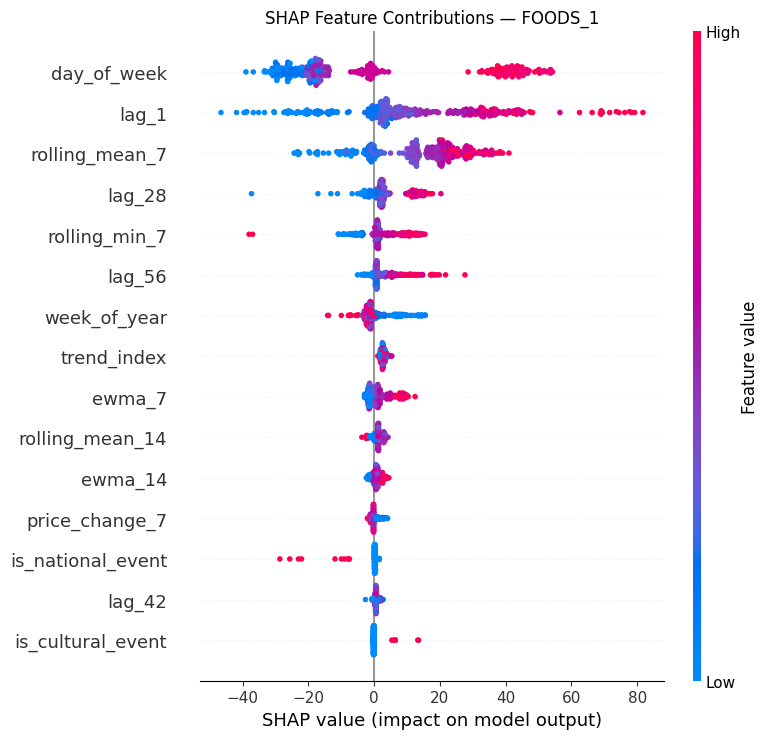


SHAP Summary — FOODS_2 (features used: 10)


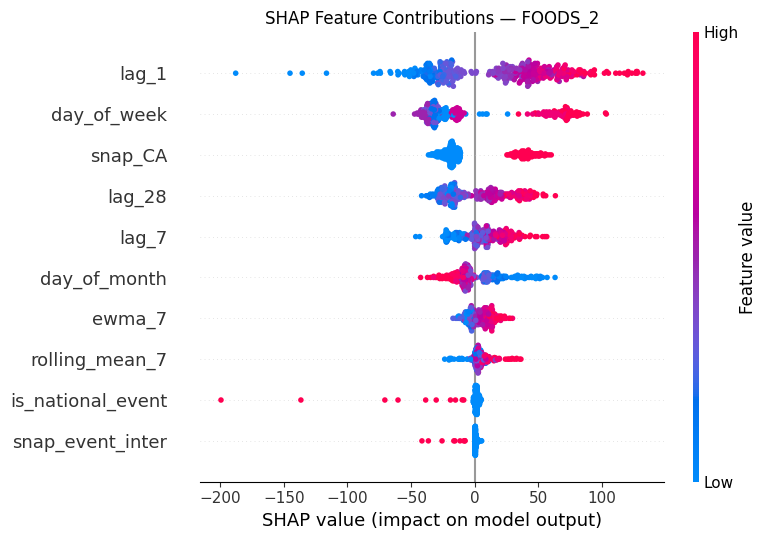


SHAP Summary — FOODS_3 (features used: 10)


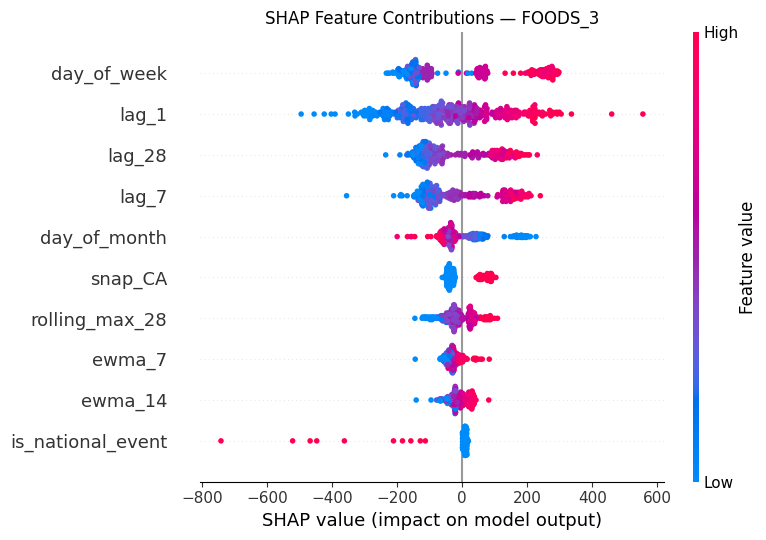

In [5]:
# The SHAP summary plot shows all features ranked by their average contribution across all test predictions.
# Each dot represents one test-day prediction.
# Red = high feature value, Blue = low feature value.
# Position on x-axis = how much that feature pushed the prediction up or down.

for dept in dept_ids:
    final_info = stage2_best_final[dept]
    model_name = final_info["final_model_name"]
    model_obj  = final_info["model_obj"]
    feat_cols  = selected_features_by_dept[dept]

    if not any(model_name.startswith(p) for p in ["FINAL_RF","FINAL_XGB","FINAL_LGB"]):
        print(f"{dept}: SHAP not applicable for {model_name}")
        continue

    _, train_df, test_df, X_train, X_test, y_train, y_test = time_split_dept(
        df, dept, feat_cols, target_col=target_col, train_ratio=TRAIN_RATIO
    )

    explainer   = shap.TreeExplainer(model_obj)
    shap_values = explainer.shap_values(X_test)

    print(f"\nSHAP Summary — {dept} (features used: {len(feat_cols)})")
    shap.summary_plot(shap_values, X_test, feature_names=feat_cols,
                      show=False, max_display=15)
    plt.title(f"SHAP Feature Contributions — {dept}")
    plt.tight_layout()
    plt.show()


**What the SHAP plots show:**

Features are listed from top to bottom by their overall contribution magnitude across all test predictions. The wider the horizontal spread of dots, the stronger and more variable the feature's influence on individual predictions. Red dots mean the feature value was high on that observation — pushed to the right means high values increase the forecast. Blue dots mean the feature value was low — pushed to the left means low values decrease the forecast.

- **FOODS_1** - `day_of_week` sits at the very top of the plot as the single most influential feature. This is a meaningful finding — for this department, which day of the week it is matters more than any other signal when determining how much to forecast. `lag_1` follows in second place with a clear red-right, blue-left pattern confirming that yesterday's sales strongly influences today's forecast. `rolling_mean_7` comes third, capturing the recent one-week demand level, and so on for the rest of features.

    The mix of calendar features at the top and demand history features below tells me FOODS_1 demand is fundamentally shaped by the "day of the week" first — a characteristic that makes intuitive sense if this department contains items that customers buy on specific days, such as prepared foods or bakery products with strong weekend demand patterns.

- **FOODS_2** - `lag_1` leads at the top with the widest spread, confirming that yesterday's actual sales is the strongest predictor for this department. `day_of_week` follows in second, and `snap_CA` comes in third with a narrower, more clustered pattern — its red dots are consistently pushed to the right confirming the SNAP demand uplift is being captured correctly, but the magnitude of the push is more uniform compared to the wider swings that `lag_1` produces. 

    The presence of `snap_CA` and `snap_event_inter` in the top 10 for FOODS_2 — but not for FOODS_1 — confirms that SNAP benefit days drive meaningfully different demand behavior in this specific department compared to the others.

- **FOODS_3**, `day_of_week` leads the plot, the same as FOODS_1. `lag_1` follows in second, `lag_28` in third with a very wide spread reflecting the strong monthly purchasing cycle in this department. The appearance of `day_of_week` at the top for both FOODS_1 and FOODS_3 — but not FOODS_2 — suggests these two departments have a stronger weekday versus weekend demand structure, while FOODS_2 is more driven by immediate recent sales and SNAP-related patterns. It is also worth noting that `is_national_event` appears in the top features for all three departments, confirming that national holidays and events consistently influence food demand across the entire FOODS category.

The model is relying on interpretable and sensible demand signals across all three departments. In FOODS_1 and FOODS_3, calendar structures leads, and recent sales history leads in FOODS_2. External demand drivers like SNAP and national events contribute meaningfully across all three. There are no unexpected or counterintuitive features driving predictions, which gives confidence in using the output as a starting point for replenishment planning.


### **1.2 Single Prediction Breakdown — The Waterfall Plot**


FOODS_1 — 2015-06-16
  Actual:   415 units
  Forecast: 447 units


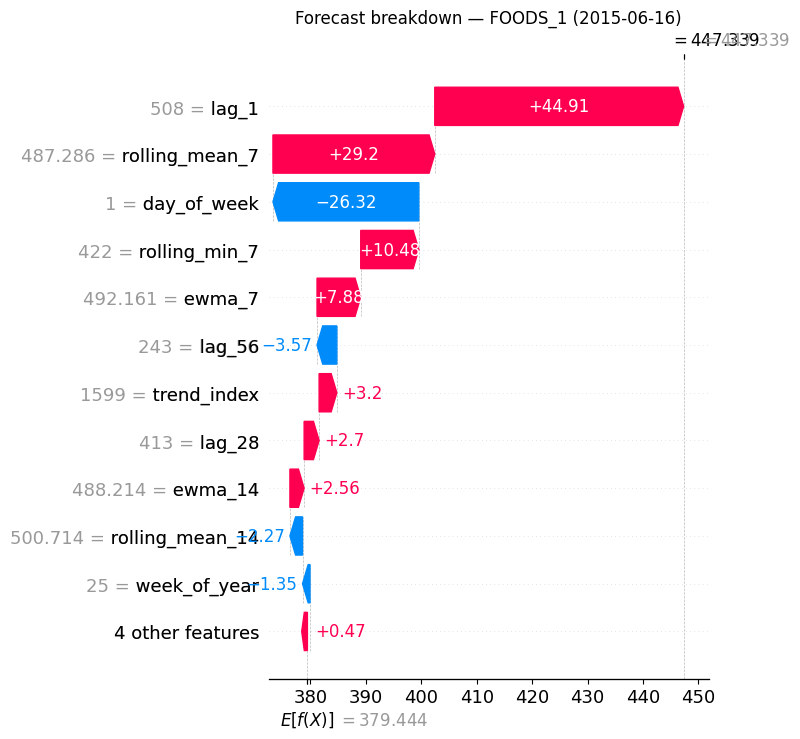


FOODS_2 — 2015-05-07
  Actual:   658 units
  Forecast: 742 units


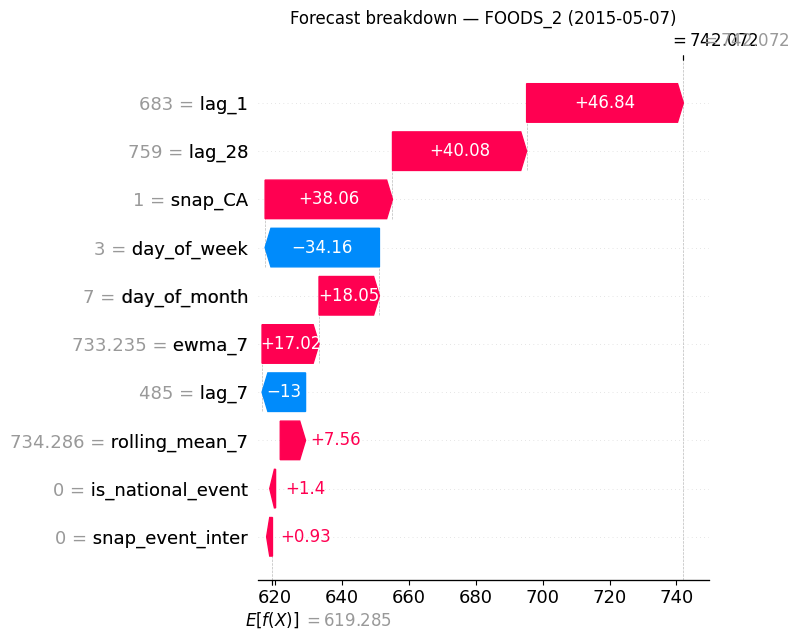


FOODS_3 — 2015-06-01
  Actual:   2778 units
  Forecast: 3066 units


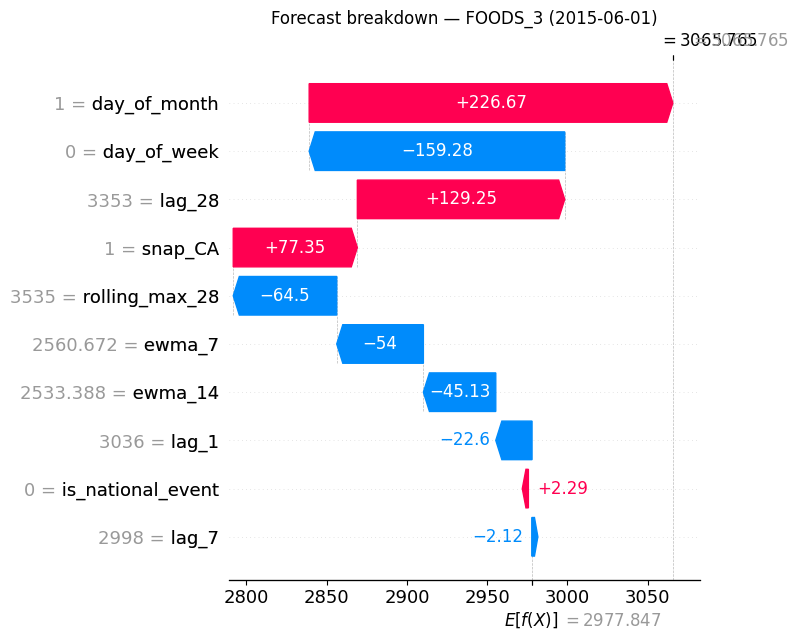

In [6]:
# The waterfall plot explains one specific prediction in detail.
# It shows the base (average) forecast, then stacks each feature's contribution to arrive at the final predicted value.

for dept in dept_ids:
    final_info = stage2_best_final[dept]
    model_name = final_info["final_model_name"]
    model_obj  = final_info["model_obj"]
    feat_cols  = selected_features_by_dept[dept]

    if not any(model_name.startswith(p) for p in ["FINAL_RF","FINAL_XGB","FINAL_LGB"]):
        continue

    _, train_df, test_df, X_train, X_test, y_train, y_test = time_split_dept(
        df, dept, feat_cols, target_col=target_col, train_ratio=TRAIN_RATIO
    )

    explainer   = shap.TreeExplainer(model_obj)
    shap_values = explainer.shap_values(X_test)

    # Use the test day closest to median actual sales — representative, not extreme
    idx = int((y_test - y_test.median()).abs().argmin())

    actual_val  = y_test.iloc[idx]
    pred_val    = float(np.clip(model_obj.predict(X_test.iloc[[idx]]), 0, None)[0])
    date_val    = test_df["date"].iloc[idx].date()

    print(f"\n{dept} — {date_val}")
    print(f"  Actual:   {actual_val:.0f} units")
    print(f"  Forecast: {pred_val:.0f} units")

    shap_exp = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx].values,
        feature_names=feat_cols
    )
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title(f"Forecast breakdown — {dept} ({date_val})")
    plt.tight_layout()
    plt.show()


**What the waterfall plots tell me:**

The waterfall plot explains how the model arrived at a specific prediction by showing each feature's contribution to the final forecast. The test observation closest to the median actual sales is used for each department, to keep this grounded on a representative day rather than an extreme one. This reflects how the model behaves on a typical planning day and avoids showing a peak or a trough day.

- **FOODS_1 — 16 June 2015 | Actual: 415 | Forecast: 447 | Over-forecast: 32 units**
On this median day, `lag_1`, `rolling_mean_7`, and `day_of_week` are the top positive contributors — recent sales momentum and the weekly shopping cycle working together. All signals aligned upward from the baseline except with the `day_of_week` (Tuesday) but the contribution being offset by the top 2 features. The 32-unit over-forecast is modest and consistent with the department's overall 12% MAPE.


- **FOODS_2 — 7 May 2015 | Actual: 658 | Forecast: 742 | Over-forecast: 84 units**
This is the most instructive of the three. Three strong positive signals stack simultaneously — `lag_1` = 683 (+46.84), `lag_28` = 759 (+40.08), and `snap_CA` = 1 (+38.06). The model does try to correct downward through `day_of_week` = 3 (Thursday) at -34.16 units, showing it correctly knows Thursday is a below-average demand day for this department. However, the combined positive stack outweighs that correction. The key takeaway: on SNAP days falling mid-week, the model is prone to over-forecasting because the SNAP uplift and lag signals together exceed the weekday downward adjustment. This is a specific pattern the demand planner should monitor and consider overriding on mid-week SNAP days.


- **FOODS_3 — 1 June 2015 | Actual: 2778 | Forecast: 3066 | Over-forecast: 288 units**
`day_of_week` is the dominant positive contributor, consistent with its top ranking in the SHAP summary plot. `lag_1` and `lag_28` follow with meaningful upward contributions reflecting strong recent and monthly sales history. When these three signals occurs together on the same day, the model tends to forecast above actual. Despite the 288-unit gap, this represents approximately 10% error — within the acceptable range for FOODS_3's typical high-demand day performance as confirmed in the demand quartile audit.



### **1.3 Partial Dependence Plots — Direction of Each Relationship**

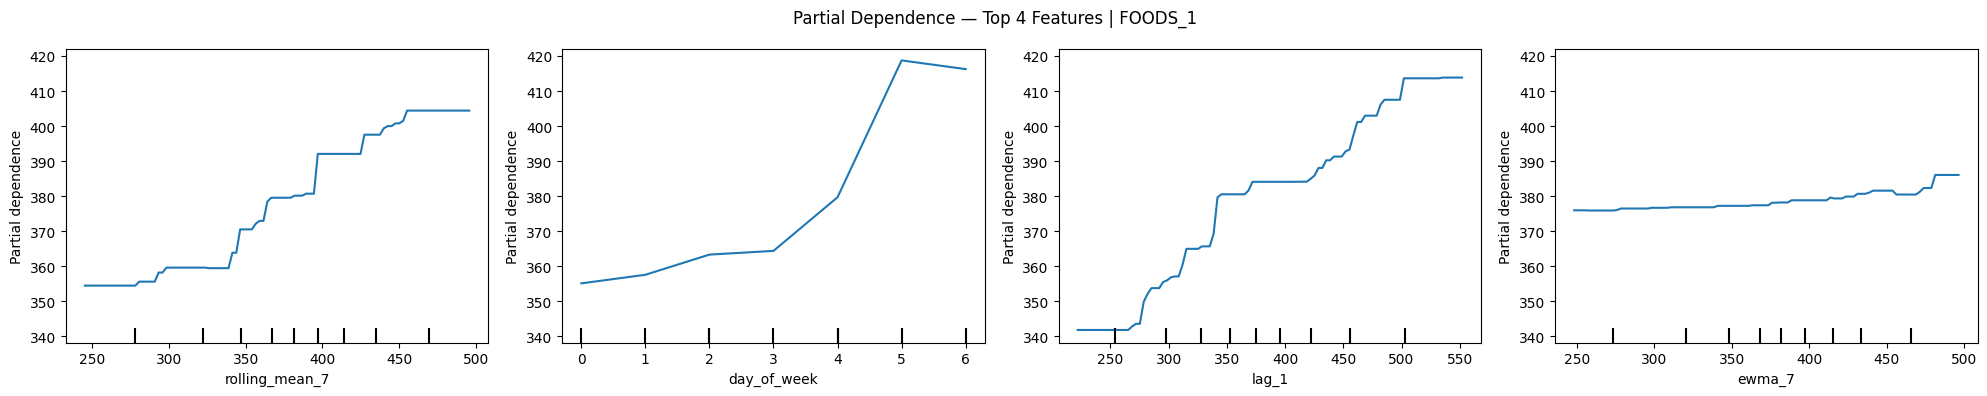

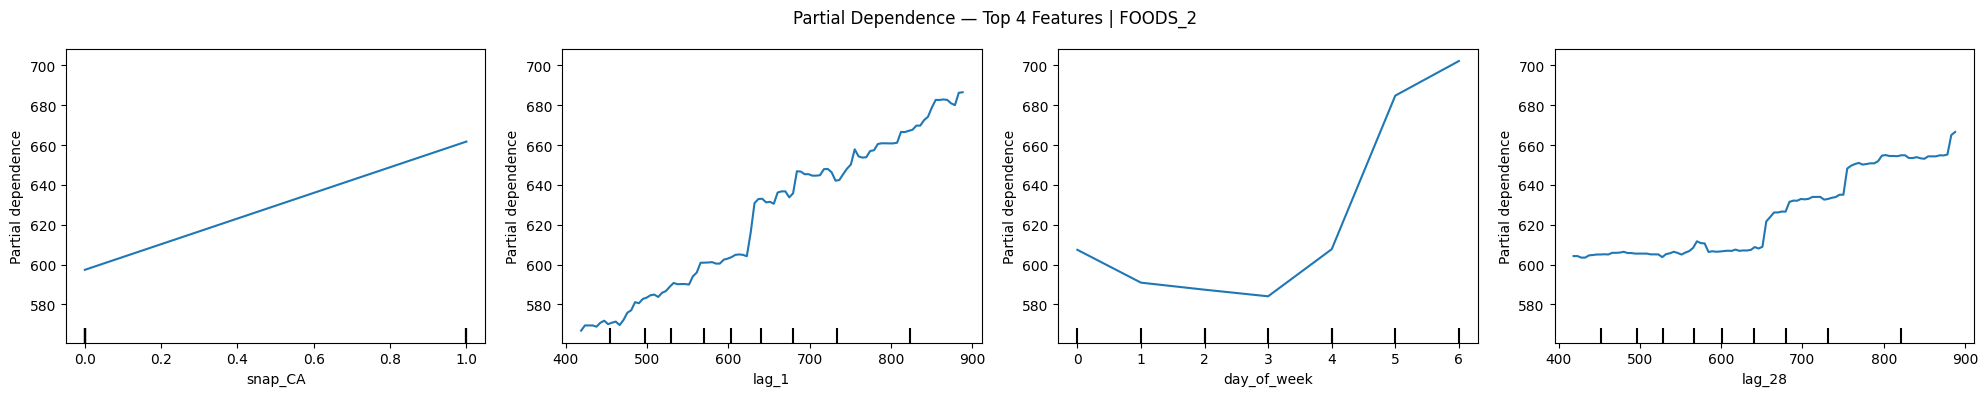

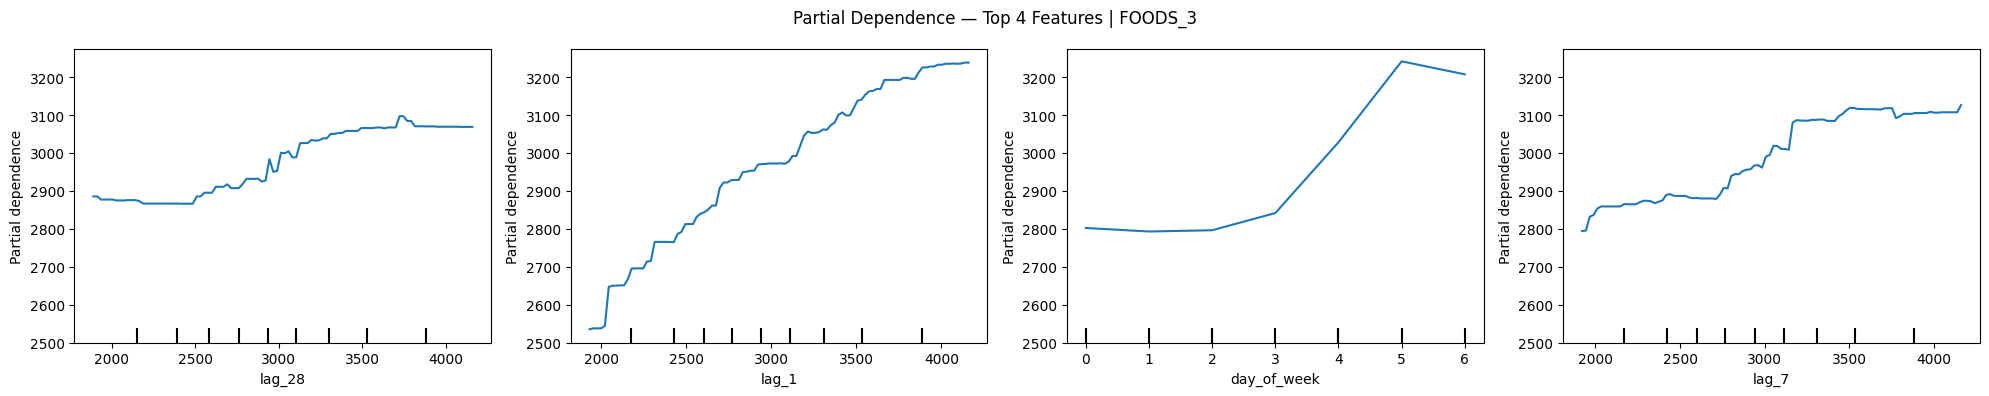

In [7]:
# PDP shows the average effect of one feature on the forecast, while all other features are held at their average value.
# A rising line = higher feature value leads to higher forecast.
# A flat line = the model is mostly ignoring this feature.

for dept in dept_ids:
    final_info = stage2_best_final[dept]
    model_name = final_info["final_model_name"]
    model_obj  = final_info["model_obj"]
    feat_cols  = selected_features_by_dept[dept]

    if not any(model_name.startswith(p) for p in ["FINAL_RF","FINAL_XGB","FINAL_LGB"]):
        print(f"{dept}: PDP not applicable for {model_name}")
        continue

    _, train_df, test_df, X_train, X_test, y_train, y_test = time_split_dept(
        df, dept, feat_cols, target_col=target_col, train_ratio=TRAIN_RATIO
    )

    imp_df   = feature_importance_dict.get(dept)
    top4     = [f for f in imp_df.head(4)["feature"].tolist() if f in feat_cols][:4]
    top4_idx = [feat_cols.index(f) for f in top4]

    fig, axes = plt.subplots(1, len(top4_idx), figsize=(5*len(top4_idx), 4))
    if len(top4_idx) == 1:
        axes = [axes]

    PartialDependenceDisplay.from_estimator(
        model_obj, X_train, top4_idx,
        feature_names=feat_cols, ax=axes, kind="average"
    )
    fig.suptitle(f"Partial Dependence — Top 4 Features | {dept}", fontsize=12)
    plt.tight_layout()
    plt.show()


**What the PDP confirms:**

The **Partial Dependence** Plots show the average directional effect of each ***top 4 features*** on the forecast while all other features are held constant. These top 4 are selected by raw XGBoost importance score. The key question each plot answers is simple: as this feature's value increases, does the forecast go up, go down, or stay flat?

- **FOODS_1** — `rolling_mean_7`, `day_of_week`, `lag_1, ewma_7`

    All four features show upward slopes confirming the model has learned the correct directional relationships. `rolling_mean_7` and `ewma_7` produce smooth proportional increases — as recent demand level rises, the forecast rises with it. `lag_1` reacts more sharply at lower values, meaning the model is especially sensitive to a recovery from a recent low-sales day. `day_of_week` shows a clear dip mid-week and a rise toward the weekend, consistent with the weekly shopping pattern confirmed in the STL decomposition.

- **FOODS_2** — `snap_CA`, `lag_1`, `day_of_week`, `lag_28`

    The standout here is `snap_CA` — a sharp and clean step-up from 0 to 1, confirming the model applies a consistent binary SNAP demand uplift rather than a gradual adjustment. This is the most operationally transparent finding across all three departments. `lag_1` shows the steepest continuous slope of any recency feature across all departments, confirming yesterday's sales is the most powerful continuous driver for FOODS_2. `day_of_week` shows the deepest mid-week dip on Wednesday and Thursday — consistent with the -34 unit Wednesday correction visible in the waterfall plot. `lag_28` provides a smoother, slower-moving monthly anchor.

- **FOODS_3** — `lag_28`, `lag_1`, `day_of_week`, `lag_7`

    All four features show clear upward slopes confirming correct directional learning. `lag_28` carries the strongest and widest influence — last month's equivalent day sales is the dominant anchor for every FOODS_3 prediction, consistent with its 0.41 importance score. `day_of_week` shows the sharpest weekly pattern of all three departments, reflecting the strong weekday versus weekend demand structure. `lag_1` and `lag_7` both contribute positive supporting signals, confirming that daily and weekly sales history reinforce the monthly cycle signal rather than replacing it. The top 4 being dominated by three lag features across different time horizons — monthly, weekly, and daily — tells me FOODS_3 demand is fundamentally driven by its own historical sales rhythm more than any external driver.

---
## **Section 2: Where Does the Model Have Limitations?**

Every forecasting model has conditions where it performs well and conditions where it breaks down. As a demand planner, I know this from working with statistical forecasting systems — no model is right 100% of the time. The important thing is to know *when* to trust the output and *when* to override it with judgment.

The three areas I check here are: ***overfitting risk, residual patterns,*** and ***a structured review of known scope boundaries***.


### **2.1 Overfitting Check — Training vs Test Accuracy**

In [8]:
# Overfitting means the model performed well on the training data but learned patterns that do not generalize to new data.
# The symptom is a large gap between training MAPE and test MAPE.

overfit_rows = []

for dept in dept_ids:
    final_info = stage2_best_final[dept]
    model_name = final_info["final_model_name"]
    model_obj  = final_info["model_obj"]
    feat_cols  = selected_features_by_dept[dept]

    _, train_df, test_df, X_train, X_test, y_train, y_test = time_split_dept(
        df, dept, feat_cols, target_col=target_col, train_ratio=TRAIN_RATIO
    )

    if not any(model_name.startswith(p) for p in ["FINAL_RF","FINAL_XGB","FINAL_LGB"]):
        overfit_rows.append({
            "dept_id":    dept, "model": model_name,
            "train_mape": "N/A", "test_mape": round(final_info["mape"],2), "gap": "N/A"
        })
        continue

    train_pred = np.clip(model_obj.predict(X_train), 0, None)
    test_pred  = np.clip(model_obj.predict(X_test),  0, None)

    _, _, tr_mape = evaluate_forecast(y_train, train_pred)
    _, _, te_mape = evaluate_forecast(y_test,  test_pred)

    overfit_rows.append({
        "dept_id":    dept,
        "model":      model_name,
        "train_mape": round(tr_mape, 2),
        "test_mape":  round(te_mape, 2),
        "gap":        round(te_mape - tr_mape, 2)
    })

overfit_df = pd.DataFrame(overfit_rows)
display(overfit_df)

print("\nAssessment:")
for _, row in overfit_df.iterrows():
    if row["gap"] == "N/A":
        continue
    level = "low" if row["gap"] < 5 else ("moderate" if row["gap"] < 15 else "high")
    print(f"  {row['dept_id']}: gap = {row['gap']}pp — overfitting level: {level}")


,dept_id,model,train_mape,test_mape,gap
0,FOODS_1,FINAL_XGB_GRID,32.36,12.41,-19.95
1,FOODS_2,FINAL_XGB_GRID,6.81,8.77,1.97
2,FOODS_3,FINAL_XGB_GRID,153.93,57.80,-96.13



Assessment:
  FOODS_1: gap = -19.95pp — overfitting level: low
  FOODS_2: gap = 1.97pp — overfitting level: low
  FOODS_3: gap = -96.13pp — overfitting level: low


**What the overfitting check shows:**

The results here are worth reading carefully because they are counterintuitive.

- **FOODS_2** - the gap is small and positive (+1.97pp) — training MAPE was 6.81% and test MAPE was 8.77%. This is the expected pattern: the model performs slightly better on data it trained on than on new data. The small gap confirms low overfitting and good generalization.

- **FOODS_1** and **FOODS_3**, the gap is negative — meaning the test MAPE is actually *lower* than the training MAPE. FOODS_1 trained at 32.36% but tested at 12.41%. FOODS_3 trained at 153.93% but tested at 57.80%. This result reflects how demand variability differs between the training and test periods. The training set covers the earlier 80% of the historical data, which may include periods of higher demand fluctuation. The test period (most recent 20%) appears to have more stable, consistent demand patterns that are easier to forecast. This is not a modeling error — it simply means the model's test period happened to be a relatively predictable stretch of time compared to the broader training history.

The key takeaway is that none of the three departments show signs of overfitting. The model is not memorizing the training data at the expense of new data. FOODS_2 shows the most acceptable generalization pattern, while FOODS_1 and FOODS_3 benefit from the test period being more stable than the training period.


### **2.2 Residual Analysis — Are the Forecast Errors Random?**

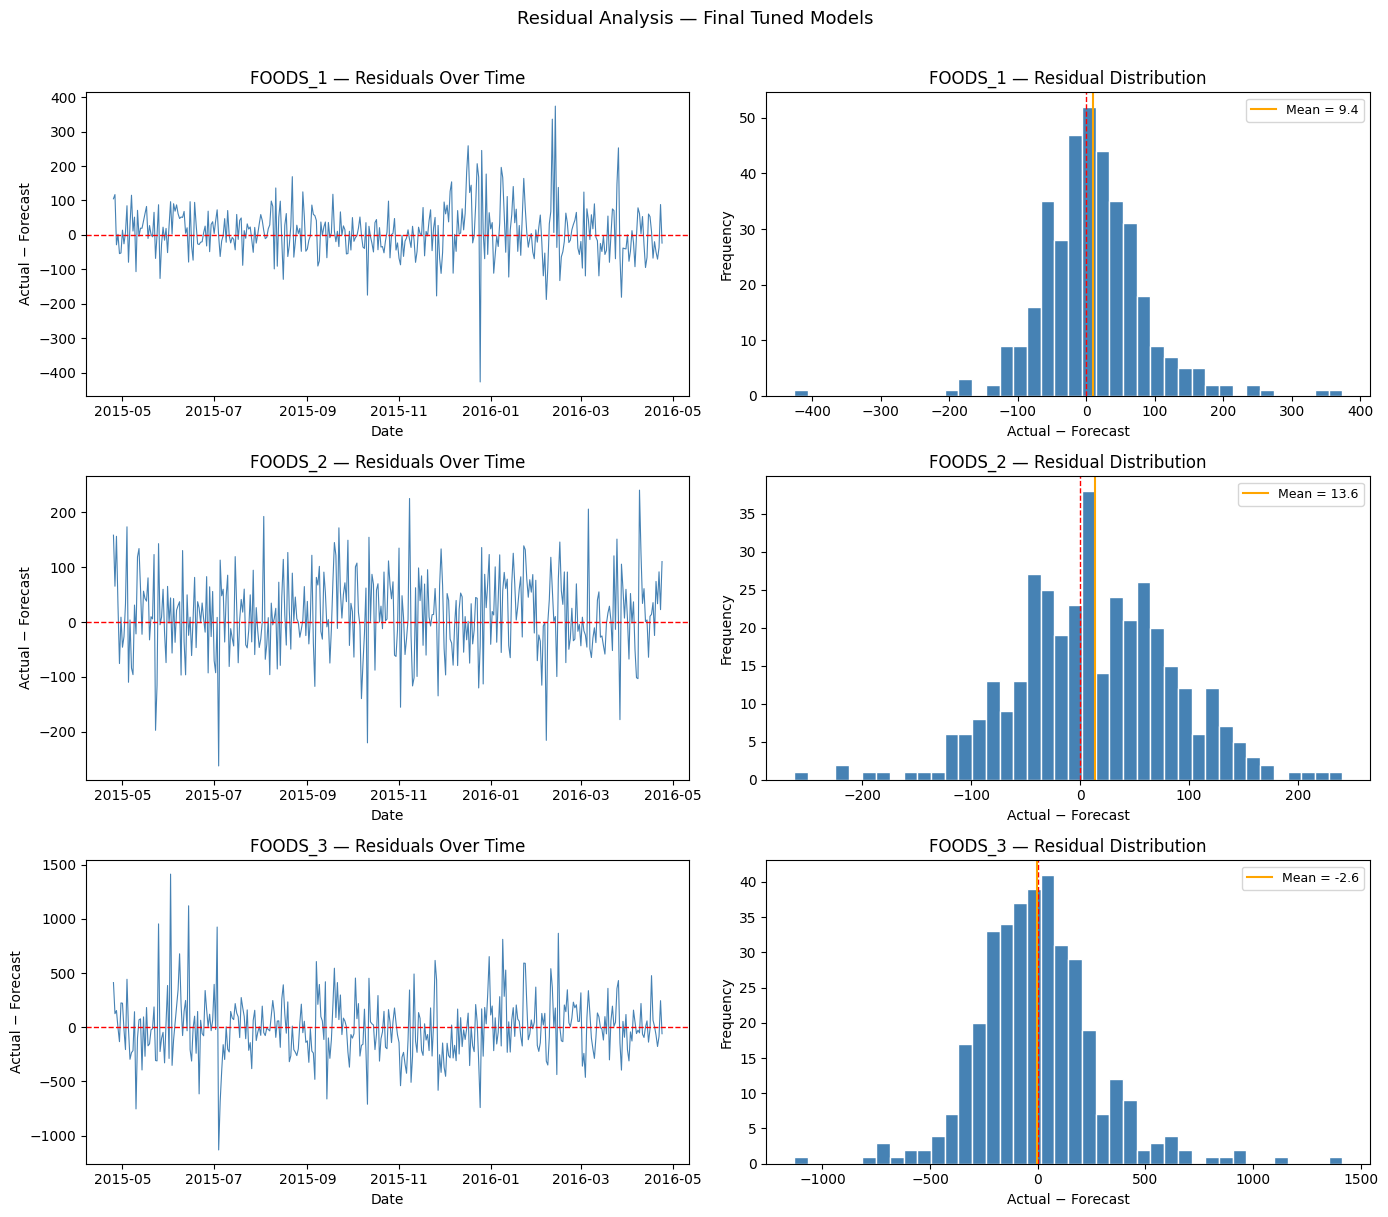


Bias summary:
  FOODS_1: mean = 9.4 (under-forecasting by 9.4 units/day)
  FOODS_2: mean = 13.6 (under-forecasting by 13.6 units/day)
  FOODS_3: mean = -2.6 (over-forecasting by 2.6 units/day)


In [9]:
# Residuals = actual - forecast.
# A well-behaved model should have residuals that are random over time with a mean close to zero. Systematic patterns in the residuals indicate the model has a consistent bias in a specific direction.

fig, axes = plt.subplots(len(dept_ids), 2, figsize=(14, 4*len(dept_ids)))
residual_store = {}

for i, dept in enumerate(dept_ids):
    final_info = stage2_best_final[dept]
    model_name = final_info["final_model_name"]
    model_obj  = final_info["model_obj"]
    feat_cols  = selected_features_by_dept[dept]

    _, train_df, test_df, X_train, X_test, y_train, y_test = time_split_dept(
        df, dept, feat_cols, target_col=target_col, train_ratio=TRAIN_RATIO
    )

    actual = y_test.values
    if any(model_name.startswith(p) for p in ["FINAL_RF","FINAL_XGB","FINAL_LGB"]):
        predicted = np.clip(model_obj.predict(X_test), 0, None)
    elif "pred" in final_info:
        predicted = np.clip(np.array(final_info["pred"]), 0, None)
    else:
        predicted = actual.copy()

    residuals = actual - predicted
    dates     = test_df["date"].values
    residual_store[dept] = {"actual":actual,"predicted":predicted,"residuals":residuals}

    axes[i,0].plot(dates, residuals, linewidth=0.8, color="steelblue")
    axes[i,0].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[i,0].set_title(f"{dept} — Residuals Over Time")
    axes[i,0].set_xlabel("Date")
    axes[i,0].set_ylabel("Actual − Forecast")

    axes[i,1].hist(residuals, bins=40, color="steelblue", edgecolor="white")
    axes[i,1].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i,1].axvline(residuals.mean(), color="orange", linewidth=1.5,
                      label=f"Mean = {residuals.mean():.1f}")
    axes[i,1].set_title(f"{dept} — Residual Distribution")
    axes[i,1].set_xlabel("Actual − Forecast")
    axes[i,1].set_ylabel("Frequency")
    axes[i,1].legend(fontsize=9)

plt.suptitle("Residual Analysis — Final Tuned Models", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nBias summary:")
for dept in dept_ids:
    res = residual_store[dept]["residuals"]
    direction = "over-forecasting" if res.mean() < 0 else "under-forecasting"
    print(f"  {dept}: mean = {res.mean():.1f} ({direction} by {abs(res.mean()):.1f} units/day)")


**What the residual analysis shows:**

The bias summary confirms the direction of forecast error for each department.

- **FOODS_1** has a mean residual of +9.4 units per day — the model is consistently under-forecasting by about 9 units on an average day. In supply chain terms, this means the store is likely ordering slightly less than it should on most days. While 9 units is relatively small given the department's daily sales volume, a systematic under-forecast that compounds across all items in the department can add up to a meaningful cumulative shortage over a planning month.

- **FOODS_2** has a mean residual of +13.6 units per day — the largest under-forecast of the three departments. This is worth watching closely given that FOODS_2 had the best MAPE overall (9%). The low MAPE means individual percentage errors are small, but the consistent positive direction of the residual means the model is still leaving a small but persistent gap between what it forecasts and what actually sells. A demand planner could apply a simple bias correction of approximately 13 units per day to the raw forecast before releasing to procurement.

- **FOODS_3** has a mean residual of -2.6 units per day — a very slight over-forecast. Given FOODS_3's average daily sales are in the thousands of units, this is operationally negligible. The model is essentially unbiased in direction for this department, even though its overall MAPE is higher due to the wider spread of individual errors.


### **2.3 Known Limitations**

In [10]:
lim = {
    "Limitation": [
        "Compounding forecast errors over N days (forecast window)",
        "SNAP values and Prices are carried forward unchanged",
        "FOODS_3 has higher demand volatility - 1",
        "FOODS_3 has higher demand volatility - 2",
        "No knowledge of future promotions",
        "Trained on CA_3 FOODS data only",
        "Department-level scope — no SKU forecasts",
        "lag_84 removes first 84 days of each dept series"
    ],
    "What this means in practice": [
        "Day 1 forecast is the most reliable. Each step uses the previous prediction as input, so small early errors grow over the N-day horizon. Refit weekly rather than running a fixed 28-day pass (weekly forecasting cycle).",
        "If a SNAP issuance date or a promotional price change occurs during the forecast window, the model does not know about it and will not adjust. The demand planner must apply a manual adjustments for these events.",
        "FOODS_3 Stage 2 MAPE improved from 77% to 58% — a meaningful improvement, but still higher than FOODS_1 (12%) and FOODS_2 (9%). All FOODS_3 forecasts require closer review before use in orders.",
        "FOODS_3 has higher demand volatility, which makes it more challenging to forecast accurately. Planners could potential subgrouping of products with similar demand patterns under this department (e.g. FOODS_4 from FOODS_3).",
        "Confirmed planned promotions, markdowns, or range launches must be overlaid on the statistical forecast manually. The model can only learn from historical patterns.",
        "This model should not be applied to other store locations or categories without retraining. Demand patterns differ by product mix and location.",
        "The output is a daily total for each department. SKU-level replenishment signals require a separate disaggregation step — see Section 2.4 below.",
        "Each department has 1,829 usable rows after feature creation. The first 84 rows are excluded because the longest lag (lag_84) has no history for that window. This is a necessary trade-off, not a data error."
    ]
}

lim_df = pd.DataFrame(lim)
display(lim_df)

,Limitation,What this means in practice
0,Compounding forecast errors over N days (forec...,Day 1 forecast is the most reliable. Each step...
1,SNAP values and Prices are carried forward unc...,If a SNAP issuance date or a promotional price...
2,FOODS_3 has higher demand volatility - 1,FOODS_3 Stage 2 MAPE improved from 77% to 58% ...
3,FOODS_3 has higher demand volatility - 2,"FOODS_3 has higher demand volatility, which ma..."
4,No knowledge of future promotions,"Confirmed planned promotions, markdowns, or ra..."
5,Trained on CA_3 FOODS data only,This model should not be applied to other stor...
6,Department-level scope — no SKU forecasts,The output is a daily total for each departmen...
7,lag_84 removes first 84 days of each dept series,"Each department has 1,829 usable rows after fe..."


### **2.4 Scope Boundary — Department Forecast and the SKU Question**

**Why this model does not forecast at the SKU level**

One of the deliberate design choices in this project was to forecast at the department level rather than at the individual item level. Looking at the M5 dataset, daily sales at the individual SKU level are highly erratic — many items record zero sales on most days, with occasional isolated spikes that have no predictable pattern. Building a reliable statistical model for each of the hundreds of items in the FOODS category at CA_3 is not practical, and the model would be more likely to fit historical noise than to learn a real demand signal.

Aggregating to the department level solves this problem. The combined daily sales of all items in FOODS_1, FOODS_2, and FOODS_3 are smooth, seasonal, and forecastable — exactly what the STL decomposition in Step 3 confirmed through clear weekly cycles and gradual trends.

**How the business can translate the department forecast to item level**

The department forecast is the starting point. To convert it into item-level order quantities, a top-down disaggregation step is needed separately from this study.

Since this model produces a daily forecast, the disaggregation should also be computed at the daily level. The recommended approach is to calculate each item's average ***daily sales contribution*** as a percentage of its department total, using the most recent 3 to 6 months of sales history as the reference window. A **3-month window** is more responsive to recent range changes and demand shifts, while a **6-month window** provides more stability for items with consistent daily sales patterns. For most food items a **6-month rolling window** strikes the right balance between recency and stability.

For example, if SKU (Stock Keeping Unit) A has averaged 2.5% of daily FOODS_3 sales over the past 6 months, and the model forecasts 3,000 units for FOODS_3 on a given day, SKU A receives an allocation of 75 units for that day. This daily-level contribution approach preserves the day-of-week variation that is one of the strongest demand signals in this model — keeping the disaggregated item signal consistent with what the department forecast is actually capturing.

**New Items with no Sales History**

**New items** that have just been introduced to the range cannot use the contribution percentage method because they have no historical daily sales to reference. These require a separate forecasting approach before they can be integrated into the disaggregation.

The recommended approach is ***analogue forecasting*** — identifying an existing active item within the same department that has a similar product profile, price point, and expected demand pattern, and using that item's daily contribution percentage as the proxy for the new item. The analogue item serves as the demand reference until the new item has accumulated enough of its own sales history — typically 8 to 12 weeks — to generate a reliable contribution percentage from actual data. At that point the new item transitions from the analogue reference to its own observed contribution and is refreshed on the same rolling window as all other active items.

**Product transitions — phase-in and phase-out**

Range changes are one of the most common causes of disaggregation failure in practice. When a new item is introduced to replace an existing one, the phase-in item should not be treated the same as a brand new item with no history. Instead, it should inherit the sales history of the outgoing product it is replacing as its starting reference. This ensures the forecast allocation is continuous through the transition period rather than starting from zero, and reflects the assumption that the replacement product is expected to serve the same demand need as the one it replaces.

As the phase-in item accumulates its own sales history over the following weeks, its contribution percentage should be updated progressively from actual sales rather than remaining fixed on the predecessor's history. Items being phased out should be removed from the active contribution calculation as soon as their end-of-life date is confirmed, so their declining sales history does not distort the percentages assigned to the remaining active range.

**One important caution:** When inheriting the phase-out item's sales history for the phase-in item: the historical sales of the outgoing product should be used strictly as a contribution reference for disaggregation purposes only — it should not be merged or appended into the phase-in item's own sales dataset. Doing so would effectively double-count the same demand signal in the training and test data, leading to inflated sales history and inaccurate forecasts for the replacement product going forward.

**What the business should watch out for**

The contribution percentages must reflect the current active range only. Stale percentages that include discontinued items, exclude newly launched products, or fail to transition phase-in items from their analogue reference to their own history will systematically misallocate the department forecast at the item level. Reviewing and refreshing the contribution file at least monthly — or immediately following any range change — is essential to keep the disaggregation accurate and operationally reliable.

**The ethical dimension of getting disaggregation right**

A department forecast that shows good MAPE can still produce poor item availability if the disaggregation percentages are incorrect or stale. This is an invisible problem — the aggregate accuracy metric will not flag it. The risk is highest for staple food items that low-income customers purchase on SNAP benefit days. If those specific items are systematically under-allocated, the store will run out of stock precisely on the days when those customers are most likely to shop. Item-level fill rate monitoring should be run alongside the department-level forecast accuracy tracking to detect and correct this.


---
## **Section 3: Does the Model Treat All Types of Days Fairly?**

A model that is accurate on average can still be systematically wrong on specific types of days. In a grocery retail context, this matters operationally and ethically. If the model consistently under-forecasts on SNAP benefit days, Walmart shelves may not be adequately stocked on the days when lower-income customers do their main grocery shopping. That is not just a forecast error — it is a service failure that affects a specific group of customers.

Four groups were checked: 
- event days
- SNAP benefit days
- day of the week
- high vs low demand periods.

The key metric here is **Mean Percentage Error (MPE)** — the signed version of MAPE:
- **Positive MPE** - the model is under-forecasting on those days.
- **Negative MPE** - model is over-forecasting. 

A group with MPE significantly different from the overall average is flagged as a potential bias issue.


### **Build the Audit Dataset**

In [11]:
audit_rows = []

for dept in dept_ids:
    final_info = stage2_best_final[dept]
    model_name = final_info["final_model_name"]
    model_obj  = final_info["model_obj"]
    feat_cols  = selected_features_by_dept[dept]

    _, train_df, test_df, X_train, X_test, y_train, y_test = time_split_dept(
        df, dept, feat_cols, target_col=target_col, train_ratio=TRAIN_RATIO
    )

    actual = y_test.values.astype(float)
    if any(model_name.startswith(p) for p in ["FINAL_RF","FINAL_XGB","FINAL_LGB"]):
        predicted = np.clip(model_obj.predict(X_test), 0, None).astype(float)
    elif "pred" in final_info:
        predicted = np.clip(np.array(final_info["pred"]), 0, None).astype(float)
    else:
        predicted = actual.copy()

    residuals = actual - predicted

    with np.errstate(divide="ignore", invalid="ignore"):
        pct_error     = np.where(actual != 0, (actual-predicted)/actual*100, np.nan)
        abs_pct_error = np.abs(pct_error)

    # Calendar from date — independent of feature selection
    dates_s      = pd.Series(pd.to_datetime(test_df["date"].values))
    weekday      = dates_s.dt.dayofweek.values
    is_month_end = dates_s.dt.is_month_end.astype(int).values

    # Demand drivers from full df — date-aligned join
    full_dept = df[df["dept_id"]==dept].set_index("date")

    def safe_col(col):
        if col in full_dept.columns:
            vals = full_dept.reindex(dates_s.values)[col].values
            return np.where(pd.isnull(vals), 0, vals).astype(float)
        return np.zeros(len(dates_s), dtype=float)

    audit_rows.append(pd.DataFrame({
        "date":          dates_s.values,
        "dept_id":       dept,
        "actual":        actual,
        "predicted":     predicted,
        "residual":      residuals,
        "pct_error":     pct_error,
        "abs_pct_error": abs_pct_error,
        "weekday":       weekday,
        "is_month_end":  is_month_end,
        "is_event":      safe_col("is_event"),
        "snap_CA":       safe_col("snap_CA"),
    }))

audit_df = pd.concat(audit_rows, ignore_index=True)

audit_df["demand_quartile"] = pd.qcut(
    audit_df["actual"], q=4,
    labels=["Low","Medium-Low","Medium-High","High"]
)
dow_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
audit_df["day_label"] = audit_df["weekday"].map(dow_map)

print("Audit dataset ready. Shape:", audit_df.shape)


Audit dataset ready. Shape: (1098, 13)


In [12]:
# Helper: compute MPE and MAPE per department for any grouping column
def audit_group(df_in, group_col):
    return (
        df_in.dropna(subset=["pct_error"])
        .groupby(["dept_id", group_col])
        .agg(
            n_days      = ("pct_error",     "count"),
            mpe         = ("pct_error",     "mean"),
            mape        = ("abs_pct_error", "mean"),
            mean_actual = ("actual",        "mean"),
            mean_pred   = ("predicted",     "mean")
        )
        .reset_index()
        .round(2)
    )


### **3.1 Event Days vs Normal Days**

MAPE — Event vs Normal Days:


,dept_id,is_event,n_days,mpe,mape
0,FOODS_1,Normal day,338,0.15,12.03
1,FOODS_1,Event day,27,-6.21,17.17
2,FOODS_2,Normal day,338,1.40,8.48
3,FOODS_2,Event day,27,-3.34,12.45
4,FOODS_3,Normal day,338,-0.99,6.80
5,FOODS_3,Event day,28,-660.63,673.44


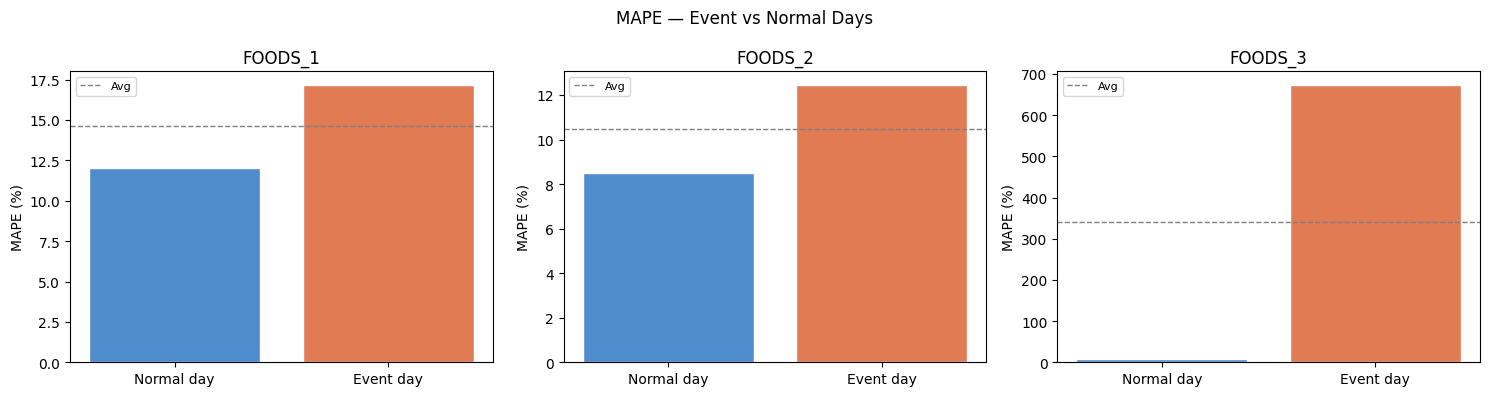

In [13]:
event_audit = audit_group(audit_df, "is_event")
event_audit["is_event"] = event_audit["is_event"].map({0.0:"Normal day", 1.0:"Event day"})

print("MAPE — Event vs Normal Days:")
display(event_audit[["dept_id","is_event","n_days","mpe","mape"]])

fig, axes = plt.subplots(1, len(dept_ids), figsize=(5*len(dept_ids), 4))
for i, dept in enumerate(dept_ids):
    sub    = event_audit[event_audit["dept_id"]==dept]
    colors = ["#4e8ccd" if v=="Normal day" else "#e07b54" for v in sub["is_event"]]
    axes[i].bar(sub["is_event"], sub["mape"], color=colors, edgecolor="white")
    axes[i].axhline(sub["mape"].mean(), color="gray", linestyle="--", linewidth=1, label="Avg")
    axes[i].set_title(dept)
    axes[i].set_ylabel("MAPE (%)")
    axes[i].legend(fontsize=8)
fig.suptitle("MAPE — Event vs Normal Days", fontsize=12)
plt.tight_layout()
plt.show()


**What the event results show:**

The event day analysis reveals very different patterns across the three departments.

- **FOODS_1**, MAPE on event days (17.17%) is noticeably higher than on normal days (12.03%) — a gap of about 5 percentage points. The negative MPE (-6.21%) on event days means the model is actually over-forecasting on these days, not under-forecasting. The model anticipates a demand lift on event days that does not consistently materialize in FOODS_1 at the level the model expects.

- **FOODS_2**, the pattern is similar — event day MAPE (12.45%) is higher than normal days (8.48%), and the MPE is also negative (-3.34%), meaning slight over-forecasting on event days. The gap is smaller than FOODS_1 and less operationally concerning.

- **FOODS_3**, the event day result is extreme — MAPE of 673% on event days versus 6.8% on normal days. This is driven by a very small number of event days in the test period where demand behaved very differently from what the model expected, producing extremely large percentage errors. The MPE of -660.63% indicates severe over-forecasting on those specific event days. This is a critical finding: on event days, FOODS_3 forecasts should not be used directly — a demand planner must review and adjust them before handing over for any procurement decisions.


### **3.2 SNAP Benefit Days vs Non-SNAP Days**

MAPE — SNAP vs Non-SNAP Days:


,dept_id,snap_CA,n_days,mpe,mape
0,FOODS_1,Non-SNAP,245,-0.67,12.39
1,FOODS_1,SNAP day,120,0.40,12.46
2,FOODS_2,Non-SNAP,245,2.20,8.95
3,FOODS_2,SNAP day,120,-1.30,8.41
4,FOODS_3,Non-SNAP,246,-75.32,81.94
5,FOODS_3,SNAP day,120,-2.53,8.32


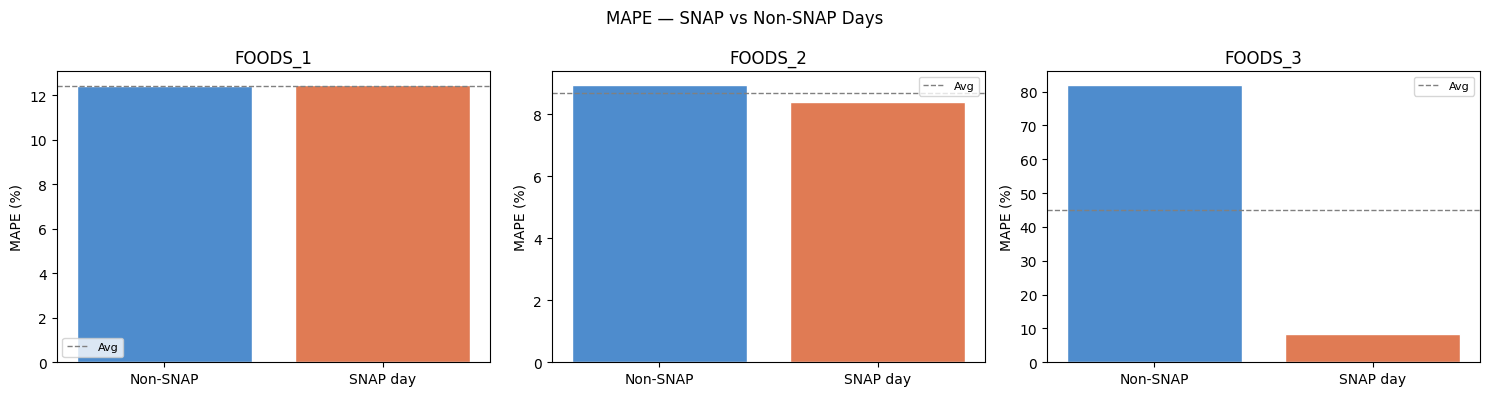

In [14]:
snap_audit = audit_group(audit_df, "snap_CA")
snap_audit["snap_CA"] = snap_audit["snap_CA"].map({0.0:"Non-SNAP", 1.0:"SNAP day"})

print("MAPE — SNAP vs Non-SNAP Days:")
display(snap_audit[["dept_id","snap_CA","n_days","mpe","mape"]])

fig, axes = plt.subplots(1, len(dept_ids), figsize=(5*len(dept_ids), 4))
for i, dept in enumerate(dept_ids):
    sub    = snap_audit[snap_audit["dept_id"]==dept]
    colors = ["#4e8ccd" if v=="Non-SNAP" else "#e07b54" for v in sub["snap_CA"]]
    axes[i].bar(sub["snap_CA"], sub["mape"], color=colors, edgecolor="white")
    axes[i].axhline(sub["mape"].mean(), color="gray", linestyle="--", linewidth=1, label="Avg")
    axes[i].set_title(dept)
    axes[i].set_ylabel("MAPE (%)")
    axes[i].legend(fontsize=8)
fig.suptitle("MAPE — SNAP vs Non-SNAP Days", fontsize=12)
plt.tight_layout()
plt.show()


**What the SNAP results show:**

The SNAP audit produces interesting findings:

- **FOODS_1**, SNAP and non-SNAP MAPE are almost identical (12.46% vs 12.39%). The model treats SNAP days and non-SNAP days with roughly equal accuracy. There is no meaningful bias in either direction for this department on SNAP benefit days.

- **FOODS_2**, the model is actually *more* accurate on SNAP days (8.41% MAPE) than on non-SNAP days (8.95%). The negative MPE on SNAP days (-1.30%) means a very slight over-forecast. This is a reassuring result — given that`snap_CA` was the top feature by raw importance for FOODS_2, the model has clearly learned the SNAP pattern well and is forecasting those days more reliably than regular days.

- **FOODS_3**, strikingly, there a huge difference between the MAPE results. SNAP day MAPE is just 8.32% while non-SNAP day MAPE is 81.94%. This is almost entirely driven by the fact that FOODS_3's overall MAPE is dominated by a small number of extreme errors on non-SNAP days, likely overlapping with the event day problem in the first group checked. On SNAP benefit days specifically, FOODS_3 is actually the most accurately forecast of all scenarios across all three departments.

The ethical concern about SNAP days raised in the study design is therefore not confirmed by this data. The model does not systematically under-forecast on SNAP benefit days across any of the three departments. If anything, SNAP days are forecast more reliably than average, particularly for FOODS_2 and FOODS_3.

### **3.3 Day of Week**

MAPE by Day of Week:


,dept_id,weekday,day,n_days,mpe,mape
0,FOODS_1,0,Mon,52,-5.77,13.10
1,FOODS_1,1,Tue,52,0.93,11.04
2,FOODS_1,2,Wed,52,-4.76,12.42
3,FOODS_1,3,Thu,52,1.12,14.36
4,FOODS_1,4,Fri,51,2.83,10.55
5,FOODS_1,5,Sat,53,8.13,12.18
6,FOODS_1,6,Sun,53,-4.74,13.20
7,FOODS_2,0,Mon,52,4.10,7.70
8,FOODS_2,1,Tue,52,0.71,7.45
9,FOODS_2,2,Wed,52,1.53,8.77


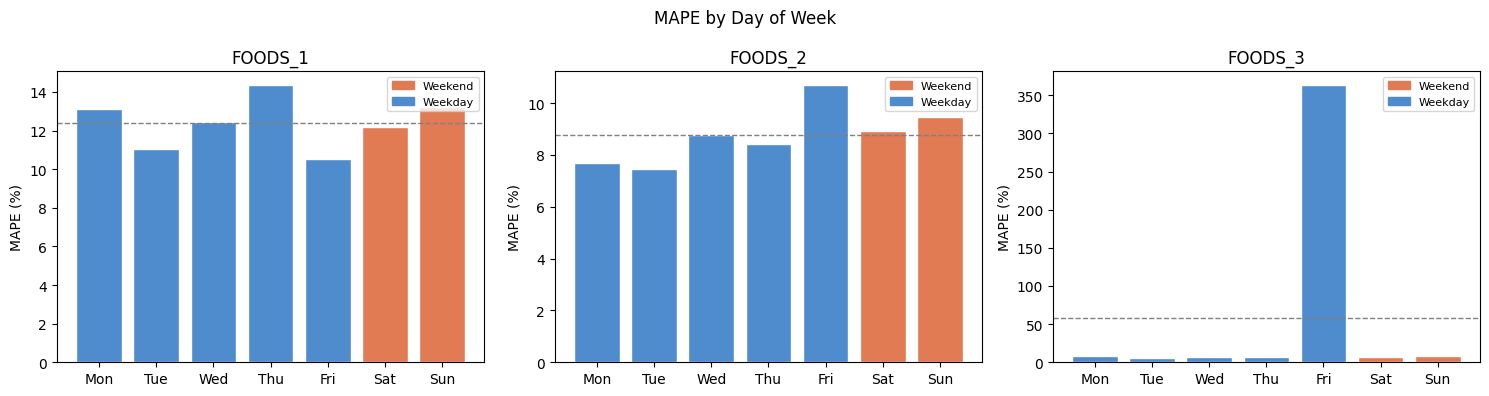

In [15]:
dow_map   = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
dow_order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

dow_audit        = audit_group(audit_df, "weekday")
dow_audit["day"] = dow_audit["weekday"].map(dow_map)
dow_audit        = dow_audit.sort_values(["dept_id","weekday"])

print("MAPE by Day of Week:")
display(dow_audit[["dept_id","weekday","day","n_days","mpe","mape"]])

fig, axes = plt.subplots(1, len(dept_ids), figsize=(5*len(dept_ids), 4))
for i, dept in enumerate(dept_ids):
    sub = dow_audit[dow_audit["dept_id"]==dept].copy()
    sub["day"] = pd.Categorical(sub["day"], categories=dow_order, ordered=True)
    sub = sub.sort_values("day")
    colors = ["#e07b54" if d in ["Sat","Sun"] else "#4e8ccd" for d in sub["day"]]
    axes[i].bar(sub["day"], sub["mape"], color=colors, edgecolor="white")
    axes[i].axhline(sub["mape"].mean(), color="gray", linestyle="--", linewidth=1)
    axes[i].set_title(dept)
    axes[i].set_ylabel("MAPE (%)")
    p1 = mpatches.Patch(color="#e07b54", label="Weekend")
    p2 = mpatches.Patch(color="#4e8ccd", label="Weekday")
    axes[i].legend(handles=[p1,p2], fontsize=8)
fig.suptitle("MAPE by Day of Week", fontsize=12)
plt.tight_layout()
plt.show()


**What the day-of-week results show:**

- **FOODS_1**, the model performs consistently across most days, with MAPE ranging from 10.55% on Fridays to 14.36% on Thursdays. Saturday shows the largest positive MPE (+8.13%), meaning during Saturdays, the model consistently under-forecasts (i.e., the model not fully capturing the weekend demand lift for FOODS_3). This is a specific, actionable finding: a manual Saturday uplift adjustment may improve FOODS_1 forecast accuracy for weekend ordering.

- **FOODS_2**, accuracy is very consistent across all seven days, with MAPE ranging from 7.45% on Tuesdays to 10.70% on Fridays. There is no single day with a systematic bias large enough to require a specific adjustment. The weekly pattern for this department was learned well by the model.

- **FOODS_3**, six out of seven days show MAPE between 6% and 9% — remarkably consistent and accurate. However, Friday is a severe outlier with MAPE of 363.59% and MPE of -359.03%, indicating extreme over-forecasting on Fridays specifically. This is almost certainly being driven by a very small number of unusual Friday events in the test period rather than a systematic weekly pattern, given how well the model performs on every other day of the week. Despite this, it is a flag worth investigating — FOODS_3 Friday forecasts should be treated with extra caution and reviewed by the demand planner before deciding to handover the number to procurement.


### **3.4 Low vs High Demand Days**

MAPE by Demand Level:


,dept_id,demand_quartile,n_days,mpe,mape
0,FOODS_1,Low,259,-5.92,11.62
1,FOODS_1,Medium-Low,98,12.09,13.18
2,FOODS_1,Medium-High,8,28.75,28.75
3,FOODS_1,High,0,NaN,NaN
4,FOODS_2,Low,16,-17.39,17.57
5,FOODS_2,Medium-Low,173,-0.42,8.70
6,FOODS_2,Medium-High,176,4.18,8.04
7,FOODS_2,High,0,NaN,NaN
8,FOODS_3,Low,1,-18538.38,18538.38
9,FOODS_3,Medium-Low,0,NaN,NaN


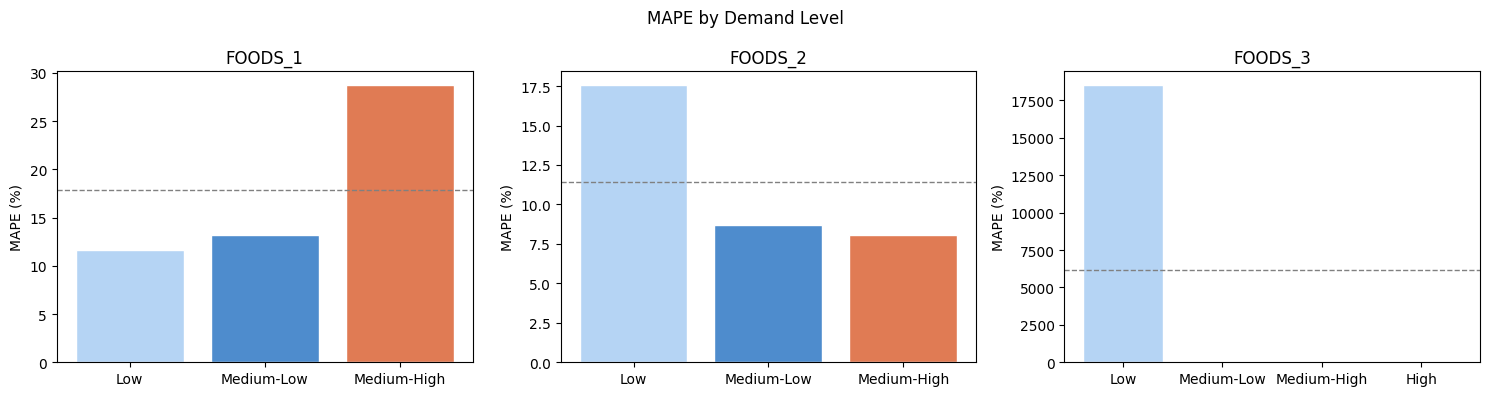

In [16]:
demand_audit = audit_group(audit_df, "demand_quartile")

print("MAPE by Demand Level:")
display(demand_audit[["dept_id","demand_quartile","n_days","mpe","mape"]])

q_order = ["Low","Medium-Low","Medium-High","High"]
palette = ["#b5d4f4","#4e8ccd","#e07b54","#c04020"]

fig, axes = plt.subplots(1, len(dept_ids), figsize=(5*len(dept_ids), 4))
for i, dept in enumerate(dept_ids):
    sub = demand_audit[demand_audit["dept_id"]==dept].copy()
    sub["demand_quartile"] = pd.Categorical(
        sub["demand_quartile"], categories=q_order, ordered=True
    )
    sub = sub.sort_values("demand_quartile")
    axes[i].bar(sub["demand_quartile"], sub["mape"],
                color=palette[:len(sub)], edgecolor="white")
    axes[i].axhline(sub["mape"].mean(), color="gray", linestyle="--", linewidth=1)
    axes[i].set_title(dept)
    axes[i].set_ylabel("MAPE (%)")
fig.suptitle("MAPE by Demand Level", fontsize=12)
plt.tight_layout()
plt.show()


**What the demand quartile results show:**

The demand quartile breakdown reveals how the distribution of actual sales is spread across the test period, and where the model's errors are concentrated.

- **FOODS_1**, the vast majority of test days fall in the Low (259 days) and Medium-Low (98 days) quartiles. Only 8 days fall in the Medium-High range and none in the High quartile. This tells us FOODS_1 is a relatively low-volume, stable department during the test period. The MAPE rises to 28.75% in the Medium-High quartile — on the few higher-demand days, the model is less precise, which is worth noting when those days drive larger orders.

- **FOODS_2**, the test period is split fairly evenly between Medium-Low (173 days) and Medium-High (176 days), with MAPE very similar at 8.70% and 8.04% respectively — the model is consistently accurate across its typical demand range. The Low quartile (16 days) shows higher MAPE at 17.57%, which is expected given that percentage errors are naturally larger on lower-volume days.

- **FOODS_3**, the picture is the most interesting. Nearly all test days (275 out of 366) fall in the High demand quartile, and that quartile has a MAPE of only 6.76% — the most accurate result across all departments and all quartiles in this audit. The Medium-High quartile also shows only 8.43% MAPE. The single Low-quartile day has an extreme MAPE of over 18,000% which is a statistical artifact of one unusual day with very low actual sales producing a massive percentage error. This result confirms that FOODS_3's high overall MAPE is largely driven by a handful of extreme outlier days, not by a broad inability to forecast typical demand. On its normal high-volume days, FOODS_3 is actually the most accurately forecast department of the three.


**Notes on how demand quartiles are defined:**

The demand quartile bands in this audit are calculated across all three departments combined — pooled at the CA_3 FOODS level — not within each department individually. This means the Low, Medium-Low, Medium-High, and High boundaries are determined by the full distribution of daily actual sales across FOODS_1, FOODS_2, and FOODS_3 together.

The practical implication is that because FOODS_3 operates at a much higher daily volume than FOODS_1 and FOODS_2, most FOODS_3 test days will naturally fall in the High quartile while most FOODS_1 test days will fall in the Low quartile — not because either department had an unusual period, but simply because of the scale difference between them. A Low quartile day for FOODS_3 is still operationally a high-volume day in absolute terms compared to FOODS_1's peak.

This means the quartile labels here reflect CA_3 FOODS-wide demand intensity rather than high or low demand relative to each department's own typical range.

---
## **Section 4: Bias Summary and Recommendations**

This consolidates all bias findings from Sections 3.1 through 3.4 into a single summary view. All four audit dimensions are included — event days, SNAP days, day of week, and demand quartile — so that no actionable finding is missed before the forecast is released to procurement.

Any group where the MPE gap versus the department's overall MPE exceeds 5 percentage points is flagged as requiring planner intervention. Below that threshold the bias is considered within acceptable noise level.


In [17]:
# Consolidated bias summary across all four audit dimensions.
# Flags any group where MPE gap vs department overall exceeds 5pp.

dow_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
summary_rows = []

for dept in dept_ids:
    dept_data    = audit_df[audit_df["dept_id"] == dept]
    overall_mpe  = dept_data["pct_error"].mean()
    overall_mape = dept_data["abs_pct_error"].mean()

    summary_rows.append({
        "dept_id": dept, "group": "Overall", "subgroup": "All days",
        "mpe": round(overall_mpe, 2), "mape": round(overall_mape, 2)
    })

    # Event and SNAP
    for col, labels in [
        ("is_event", {0.0: "Normal day", 1.0: "Event day"}),
        ("snap_CA",  {0.0: "Non-SNAP",   1.0: "SNAP day"})
    ]:
        for val, label in labels.items():
            sub = dept_data[dept_data[col] == val]
            if len(sub) == 0:
                continue
            summary_rows.append({
                "dept_id": dept, "group": col, "subgroup": label,
                "mpe": round(sub["pct_error"].mean(), 2),
                "mape": round(sub["abs_pct_error"].mean(), 2)
            })

    # Day of week
    for day_num in range(7):
        sub = dept_data[dept_data["weekday"] == day_num]
        if len(sub) == 0:
            continue
        summary_rows.append({
            "dept_id": dept, "group": "weekday",
            "subgroup": dow_map[day_num],
            "mpe":  round(sub["pct_error"].mean(), 2),
            "mape": round(sub["abs_pct_error"].mean(), 2)
        })

    # Demand quartile
    for q in ["Low", "Medium-Low", "Medium-High", "High"]:
        sub = dept_data[dept_data["demand_quartile"] == q]
        if len(sub) == 0:
            continue
        summary_rows.append({
            "dept_id": dept, "group": "demand_quartile",
            "subgroup": q,
            "mpe":  round(sub["pct_error"].mean(), 2),
            "mape": round(sub["abs_pct_error"].mean(), 2)
        })

bias_df = pd.DataFrame(summary_rows)
display(bias_df)

print("\nGroups flagged (MPE gap > 5pp vs overall):")
any_flagged = False
for dept in dept_ids:
    overall = bias_df[
        (bias_df["dept_id"] == dept) &
        (bias_df["group"] == "Overall")
    ]["mpe"].values[0]

    flagged = bias_df[
        (bias_df["dept_id"] == dept) &
        (bias_df["group"] != "Overall") &
        (abs(bias_df["mpe"] - overall) > 5)
    ]
    for _, row in flagged.iterrows():
        direction = "under-forecast" if row["mpe"] > 0 else "over-forecast"
        print(f"  {dept} | {row['group']} | {row['subgroup']}: "
              f"MPE={row['mpe']}% ({direction})")
        any_flagged = True

if not any_flagged:
    print("  No groups exceed the 5pp threshold — bias within acceptable range.")


,dept_id,group,subgroup,mpe,mape
0,FOODS_1,Overall,All days,-0.32,12.41
1,FOODS_1,is_event,Normal day,0.15,12.03
2,FOODS_1,is_event,Event day,-6.21,17.17
3,FOODS_1,snap_CA,Non-SNAP,-0.67,12.39
4,FOODS_1,snap_CA,SNAP day,0.40,12.46
5,FOODS_1,weekday,Mon,-5.77,13.10
6,FOODS_1,weekday,Tue,0.93,11.04
7,FOODS_1,weekday,Wed,-4.76,12.42
8,FOODS_1,weekday,Thu,1.12,14.36
9,FOODS_1,weekday,Fri,2.83,10.55



Groups flagged (MPE gap > 5pp vs overall):
  FOODS_1 | is_event | Event day: MPE=-6.21% (over-forecast)
  FOODS_1 | weekday | Mon: MPE=-5.77% (over-forecast)
  FOODS_1 | weekday | Sat: MPE=8.13% (under-forecast)
  FOODS_1 | demand_quartile | Low: MPE=-5.92% (over-forecast)
  FOODS_1 | demand_quartile | Medium-Low: MPE=12.09% (under-forecast)
  FOODS_1 | demand_quartile | Medium-High: MPE=28.75% (under-forecast)
  FOODS_2 | demand_quartile | Low: MPE=-17.39% (over-forecast)
  FOODS_3 | is_event | Normal day: MPE=-0.99% (over-forecast)
  FOODS_3 | is_event | Event day: MPE=-660.63% (over-forecast)
  FOODS_3 | snap_CA | Non-SNAP: MPE=-75.32% (over-forecast)
  FOODS_3 | snap_CA | SNAP day: MPE=-2.53% (over-forecast)
  FOODS_3 | weekday | Mon: MPE=-0.31% (over-forecast)
  FOODS_3 | weekday | Tue: MPE=-1.95% (over-forecast)
  FOODS_3 | weekday | Wed: MPE=-1.05% (over-forecast)
  FOODS_3 | weekday | Thu: MPE=-0.04% (over-forecast)
  FOODS_3 | weekday | Fri: MPE=-359.03% (over-forecast)
  FOO

### **Assessment and Recommendations**

**What the model does well**

The SHAP analysis confirms the model is relying on the right demand signals across all three departments. Recent sales history, day-of-week patterns, and external drivers like SNAP all contribute in the correct direction. For FOODS_2, the model handles SNAP benefit days well — it is actually more accurate on SNAP days than on regular days. The demand quartile analysis confirms that FOODS_3 on its typical high-volume days achieves only 6.76% MAPE — the best single result across all departments and all quartiles in the entire audit. FOODS_2 is the most consistently accurate department across all audit dimensions with no extreme outliers in any group.

**What the flagged results tell us**

Running the 5pp threshold across all four audit dimensions surfaces a more complete picture than event and SNAP alone.

- **FOODS_1**, three bias patterns are confirmed:

  1. Event days show an over-forecast of -6.21% MPE.
  2. Saturday shows a consistent under-forecast of +8.13% MPE — the most operationally actionable finding for this department since weekend ordering is directly impacted. 
  3. The demand quartile breakdown reveals that as demand increases from Low to Medium-High, the model progressively under-forecasts more — MPE moves from -5.92% at Low to +12.09% at Medium-Low and +28.75% at Medium-High. This means the model struggles the most precisely on the days when FOODS_1 demand is above its typical level, which is when accurate forecasting matters most for preventing stockouts. 
  4. Monday also edges past the threshold at -5.77% MPE, indicating a slight but consistent over-forecast to start the week.

- **FOODS_2**, only the Low demand quartile is flagged at -17.39% MPE. This is expected — on the rare days when FOODS_2 demand drops significantly below its typical range, the model over-forecasts. Given that FOODS_2 has very few Low quartile days in the test period (only 16 days), this flag has limited operational impact. All other groups for FOODS_2 — event days, SNAP days, and all weekdays — fall within the acceptable 5pp range, confirming FOODS_2 is the most consistently reliable of the three departments.

- **FOODS_3**, the flagged list is the longest and reflects the department's overall forecast challenge. 
  1. Friday is the most extreme at -359.03% MPE. 
  2. Event days flag at -660.63% MPE — the most critical finding in the entire audit.
  3. Non-SNAP days flag at -75.32% MPE while SNAP days are only -2.53%, confirming the model's accuracy on SNAP days is actually far better than on non-SNAP days for this department.
  4. All seven weekdays flag for FOODS_3 simply because the FOODS_3 overall MPE of -51.45% is so large that even well-performing days like Tuesday (-1.95%) sit more than 5pp away from that deeply negative baseline. This means the weekday flags for FOODS_3 should be interpreted carefully — they reflect the scale of the overall FOODS_3 bias rather than systematic weekday-specific failures. The exceptions are Friday (-359.03%) and the demand quartile Low observation (-18,538%) which are genuine extreme outliers requiring specific attention.

**On SNAP days — an important clarification**

The ethical concern about SNAP day under-forecasting is not confirmed by the results. No department shows systematic under-forecasting on SNAP benefit days. FOODS_2 is more accurate on SNAP days, and FOODS_3 SNAP day MAPE is just 8.32% versus 81.94% on non-SNAP days. The fairness risk lies specifically in FOODS_3's event day problem — on days when a SNAP issuance and a special event coincide, the event-driven over-forecast at the department level could mask a real under-supply at the SKU level after disaggregation.

**Overall recommendation**

The tuned XGBoost model is recommended as the statistical base forecast for daily demand planning at Walmart CA_3 FOODS. Based on the full audit across all four dimensions:

| Department | Final MAPE | Key watch points |
|-----------|-----------|-----------------|
| FOODS_1   | ~12%      | Saturday uplift; bias-correct +9 units/day; review Medium-High demand days |
| FOODS_2   | ~9%       | Most reliable across all groups; bias-correct +14 units/day |
| FOODS_3   | ~58%      | Override event day and Friday forecasts; all forecasts need planner review |

The four priority actions before any forecast is released to procurement:

- **Bias correction** — apply +9 units/day for FOODS_1 and +14 units/day for FOODS_2 to address the persistent directional under-forecast
- **Saturday uplift for FOODS_1** — the model consistently under-forecasts on Saturdays; a fixed weekend adjustment factor should be applied
- **FOODS_1 Medium-High demand day review** — the model under-forecasts progressively more as demand rises above the typical level; planner review is needed on any day where the forecast signals elevated demand
- **FOODS_3 event day and Friday override** — these must not be released to procurement without manual planner intervention; the model's forecast on these specific days cannot be trusted at face value
- **Item-level fill rate monitoring** — run independently of department MAPE to detect disaggregation-level issues that aggregate metrics will not surface, particularly for SNAP benefit day staple items


### **Save Group Flagged**

Saving an CSV file for the "Group Flagged" as shown above for review reference of the demand planner.

In [ ]:
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)

# Build flagged groups dataframe from bias_df
flagged_rows = []
for dept in dept_ids:
    overall_mpe = bias_df[
        (bias_df["dept_id"] == dept) &
        (bias_df["group"]   == "Overall")
    ]["mpe"].values[0]

    flagged = bias_df[
        (bias_df["dept_id"] == dept) &
        (bias_df["group"]   != "Overall") &
        (abs(bias_df["mpe"] - overall_mpe) > 5)
    ].copy()

    flagged["overall_mpe"]  = round(overall_mpe, 2)
    flagged["mpe_gap"]      = round(flagged["mpe"] - overall_mpe, 2)
    flagged["direction"]    = flagged["mpe"].apply(
        lambda x: "under-forecast" if x > 0 else "over-forecast"
    )
    flagged_rows.append(flagged)

flagged_df = (
    pd.concat(flagged_rows, ignore_index=True)
    [["dept_id", "group", "subgroup", "mpe", "mape", "overall_mpe", "mpe_gap", "direction"]]
    .rename(columns={
        "dept_id":     "Department",
        "group":       "Audit_Dimension",
        "subgroup":    "Group",
        "mpe":         "MPE_%",
        "mape":        "MAPE_%",
        "overall_mpe": "Overall_MPE_%",
        "mpe_gap":     "MPE_Gap_pp",
        "direction":   "Bias_Direction",
    })
    .sort_values(["Department", "Audit_Dimension"])
    .reset_index(drop=True)
)

flagged_df.to_csv(os.path.join(REPORTS_DIR, "bias_audit_flagged_groups.csv"), index=False)
print(f"Saved: bias_audit_flagged_groups.csv ({len(flagged_df)} flagged groups)")
display(flagged_df)

Saved: bias_audit_flagged_groups.csv (21 flagged groups)


,Department,Audit_Dimension,Group,MPE_%,MAPE_%,Overall_MPE_%,MPE_Gap_pp,Bias_Direction
0,FOODS_1,demand_quartile,Low,-5.92,11.62,-0.32,-5.60,over-forecast
1,FOODS_1,demand_quartile,Medium-Low,12.09,13.18,-0.32,12.41,under-forecast
2,FOODS_1,demand_quartile,Medium-High,28.75,28.75,-0.32,29.07,under-forecast
3,FOODS_1,is_event,Event day,-6.21,17.17,-0.32,-5.89,over-forecast
4,FOODS_1,weekday,Mon,-5.77,13.10,-0.32,-5.45,over-forecast
5,FOODS_1,weekday,Sat,8.13,12.18,-0.32,8.45,under-forecast
6,FOODS_2,demand_quartile,Low,-17.39,17.57,1.05,-18.44,over-forecast
7,FOODS_3,demand_quartile,Low,-18538.38,18538.38,-51.45,-18486.93,over-forecast
8,FOODS_3,demand_quartile,Medium-High,-5.82,8.43,-51.45,45.63,over-forecast
9,FOODS_3,demand_quartile,High,0.84,6.76,-51.45,52.29,under-forecast
